# Bao cao toi uu: Phan tich thi truong chung khoan da ma voi PySpark

Notebook nay duoc toi uu cho do an voi 3 muc tieu: 
1. Trinh bay dep va de doc cho bao cao.
2. Phan tich da ma co phieu (AAPL, TSLA, FPT, HPG, VCB, VIC, VNM).
3. Sinh nhan xet tu dong theo tung ticker dua tren chi so dinh luong.

Nguon du lieu su dung: `data_stocks_features.parquet`.

## 1. Khoi tao moi truong

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = (
    SparkSession.builder
    .appName("StockMarket-Report-Optimized")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 18:33:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/20 18:33:25 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


## 2. Load du lieu va kiem tra schema

In [2]:
parquet_path = "data_stocks_features.parquet"
df = spark.read.parquet(parquet_path)

if "time" not in df.columns and "date" in df.columns:
    df = df.withColumnRenamed("date", "time")

df = df.withColumn("time", F.col("time").cast("timestamp"))

required_cols = ["time", "ticker", "open", "high", "low", "close", "volume", "prev_close", "ma7", "daily_return"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Thieu cot bat buoc: {missing}")

df = df.orderBy("ticker", "time")

print("Da load:", parquet_path)
print("Tong so dong:", df.count())
print("So ticker:", df.select("ticker").distinct().count())
df.printSchema()
df.show(10, truncate=False)

Da load: data_stocks_features.parquet
Tong so dong: 12993
So ticker: 7
root
 |-- time: timestamp (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- ticker: string (nullable = true)
 |-- prev_close: double (nullable = true)
 |-- ma7: double (nullable = true)
 |-- daily_return: double (nullable = true)

+-------------------+------------------+-----------------+------------------+------------------+---------+------+------------------+------------------+---------------------+
|time               |open              |high             |low               |close             |volume   |ticker|prev_close        |ma7               |daily_return         |
+-------------------+------------------+-----------------+------------------+------------------+---------+------+------------------+------------------+---------------------+
|2019-01-03 00:00:00

## 3. Them feature bo sung cho bao cao
Tat ca duoc tinh theo `partitionBy(ticker).orderBy(time)` de dam bao dung chuan time series va khong leakage.

In [3]:
w = Window.partitionBy("ticker").orderBy("time")
w14 = w.rowsBetween(-13, 0)
w30 = w.rowsBetween(-29, 0)

df_feat = (
    df
    .withColumn("ma14", F.avg("close").over(w14))
    .withColumn("ma30", F.avg("close").over(w30))
    .withColumn("volatility14", F.stddev("daily_return").over(w14))
    .withColumn("lag_close_1", F.lag("close", 1).over(w))
    .withColumn("momentum_3", F.col("close") - F.lag("close", 3).over(w))
    .withColumn("future_close", F.lead("close", 1).over(w))
    .withColumn("label_up", F.when(F.col("future_close") > F.col("close"), 1).otherwise(0))
)

df_feat.select("ticker", "time", "close", "ma7", "ma14", "ma30", "volatility14", "momentum_3", "label_up").show(12, truncate=False)

+------+-------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+--------+
|ticker|time               |close             |ma7               |ma14              |ma30              |volatility14        |momentum_3          |label_up|
+------+-------------------+------------------+------------------+------------------+------------------+--------------------+--------------------+--------+
|AAPL  |2019-01-03 00:00:00|34.19317547745964 |35.48866253621175 |34.19317547745964 |34.19317547745964 |NULL                |NULL                |1       |
|AAPL  |2019-01-04 00:00:00|34.323789806748884|35.100371626390796|34.25848264210426 |34.25848264210426 |0.05250772626131738 |NULL                |1       |
|AAPL  |2019-01-07 00:00:00|35.3141057597988  |35.153805159742795|34.61035701466911 |34.61035701466911 |0.05163836773353618 |NULL                |1       |
|AAPL  |2019-01-08 00:00:00|35.51834447775036 |35.22671302334431

## 4. Dashboard chi so tong hop theo ticker

In [4]:
df_ranked = (
    df_feat
    .withColumn("rn_asc", F.row_number().over(Window.partitionBy("ticker").orderBy("time")))
    .withColumn("rn_desc", F.row_number().over(Window.partitionBy("ticker").orderBy(F.col("time").desc())))
)

summary = (
    df_ranked.groupBy("ticker")
    .agg(
        F.max(F.when(F.col("rn_asc") == 1, F.col("close"))).alias("first_close"),
        F.max(F.when(F.col("rn_desc") == 1, F.col("close"))).alias("last_close"),
        F.avg("daily_return").alias("avg_daily_return"),
        F.stddev("daily_return").alias("volatility"),
        F.avg("volume").alias("avg_volume"),
        F.max(F.when(F.col("rn_desc") == 1, F.col("ma7"))).alias("latest_ma7"),
        F.max(F.when(F.col("rn_desc") == 1, F.col("ma30"))).alias("latest_ma30"),
        F.max(F.when(F.col("rn_desc") == 1, F.col("close"))).alias("latest_close")
    )
)

summary = (
    summary
    .withColumn("total_return", (F.col("last_close") / F.col("first_close")) - 1)
    .withColumn("sharpe_proxy", F.col("avg_daily_return") / F.col("volatility"))
    .orderBy(F.desc("total_return"))
)

summary.show(truncate=False)

+------+-----------------+------------------+---------------------+--------------------+--------------------+------------------+------------------+------------------+--------------------+---------------------+
|ticker|first_close      |last_close        |avg_daily_return     |volatility          |avg_volume          |latest_ma7        |latest_ma30       |latest_close      |total_return        |sharpe_proxy         |
+------+-----------------+------------------+---------------------+--------------------+--------------------+------------------+------------------+------------------+--------------------+---------------------+
|TSLA  |20.46666717529297|390.04998779296875|0.0025205806903147014|0.04225381940780326 |1.2170886114190687E8|396.59857177734375|413.016997273763  |390.04998779296875|18.05781651952746   |0.05965332189234498  |
|AAPL  |34.19317547745964|255.69000244140625|0.0012672771806858222|0.019597571747569105|8.750954850332594E7 |262.63714599609375|265.35445652543785|255.690002441

## 5. Nhan xet tu dong theo tung ticker
Phan nay tao comment tu dong de ban dua thang vao phan nhan xet cua bao cao.

In [5]:
summary_pd = summary.toPandas()

def auto_comment(row):
    trend = "tang" if row["latest_ma7"] > row["latest_ma30"] else "giam/di ngang"

    if row["total_return"] >= 0.2 and row["volatility"] <= 0.03:
        quality = "hieu suat manh, bien dong vua phai"
    elif row["total_return"] >= 0.2 and row["volatility"] > 0.03:
        quality = "tang manh nhung rui ro bien dong cao"
    elif row["total_return"] > 0:
        quality = "co tang truong nhe"
    else:
        quality = "hieu suat chua tich cuc"

    return (
        f"Ticker {row['ticker']}: total return {row['total_return']:.2%}, "
        f"volatility {row['volatility']:.4f}, xu huong ngan han {trend}; {quality}."
    )

summary_pd["auto_comment"] = summary_pd.apply(auto_comment, axis=1)

for c in summary_pd["auto_comment"].tolist():
    print("-", c)

summary_pd[["ticker", "total_return", "volatility", "sharpe_proxy", "auto_comment"]]

- Ticker TSLA: total return 1805.78%, volatility 0.0423, xu huong ngan han giam/di ngang; tang manh nhung rui ro bien dong cao.
- Ticker AAPL: total return 647.78%, volatility 0.0196, xu huong ngan han giam/di ngang; hieu suat manh, bien dong vua phai.
- Ticker FPT: total return 474.50%, volatility 0.0173, xu huong ngan han giam/di ngang; hieu suat manh, bien dong vua phai.
- Ticker VIC: total return 217.67%, volatility 0.0213, xu huong ngan han tang; hieu suat manh, bien dong vua phai.
- Ticker HPG: total return 158.49%, volatility 0.0210, xu huong ngan han giam/di ngang; hieu suat manh, bien dong vua phai.
- Ticker VCB: total return 128.70%, volatility 0.0163, xu huong ngan han giam/di ngang; hieu suat manh, bien dong vua phai.
- Ticker VNM: total return -16.25%, volatility 0.0155, xu huong ngan han giam/di ngang; hieu suat chua tich cuc.


,ticker,total_return,volatility,sharpe_proxy,auto_comment
0,TSLA,18.057817,0.042254,0.059653,"Ticker TSLA: total return 1805.78%, volatility..."
1,AAPL,6.477808,0.019598,0.064665,"Ticker AAPL: total return 647.78%, volatility ..."
2,FPT,4.744986,0.017341,0.062444,"Ticker FPT: total return 474.50%, volatility 0..."
3,VIC,2.176675,0.021338,0.039480,"Ticker VIC: total return 217.67%, volatility 0..."
4,HPG,1.584906,0.021006,0.034779,"Ticker HPG: total return 158.49%, volatility 0..."
5,VCB,1.287012,0.016334,0.034474,"Ticker VCB: total return 128.70%, volatility 0..."
6,VNM,-0.162457,0.015515,0.001697,"Ticker VNM: total return -16.25%, volatility 0..."


## 6. Bieu do 1 - Gia dong cua chuan hoa (de so sanh da ma)

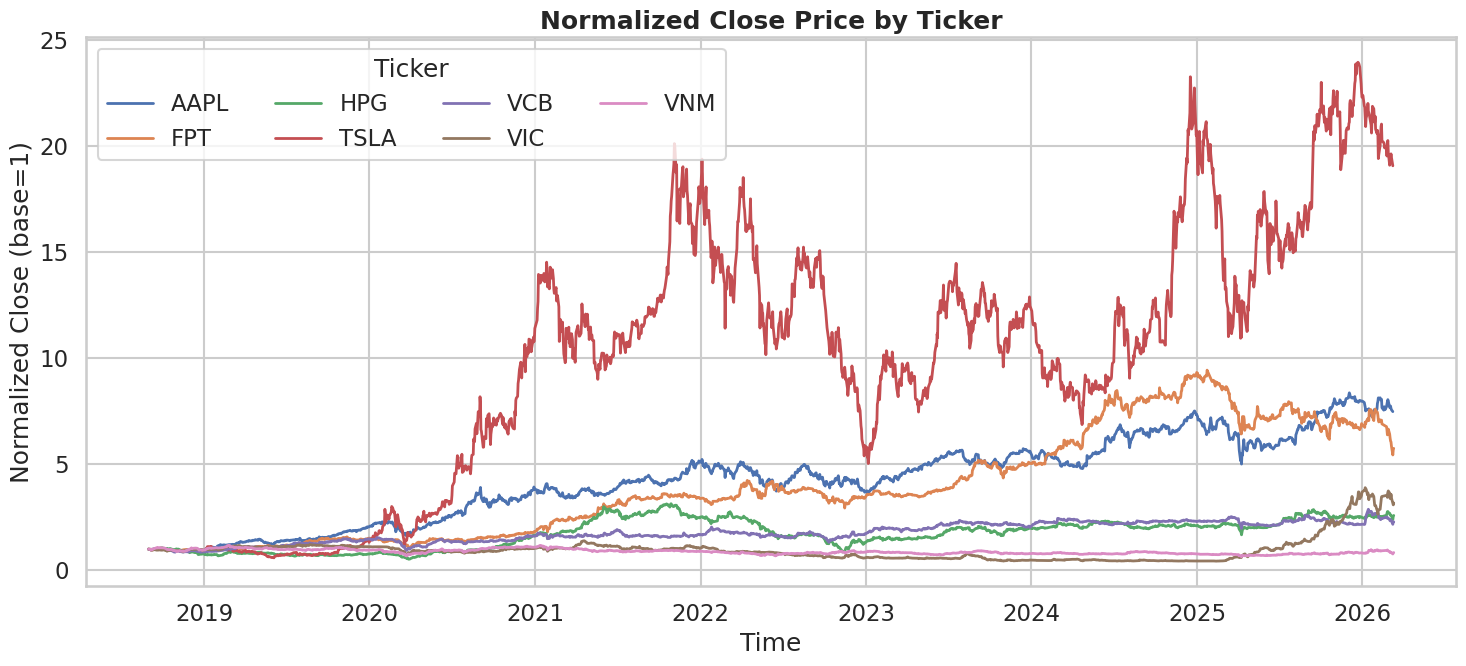

In [6]:
plot_df = df_feat.select("time", "ticker", "close").toPandas()
plot_df["time"] = pd.to_datetime(plot_df["time"])
plot_df = plot_df.sort_values(["ticker", "time"])

plot_df["norm_close"] = plot_df.groupby("ticker")["close"].transform(lambda s: s / s.iloc[0])

plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_df, x="time", y="norm_close", hue="ticker", linewidth=2)
plt.title("Normalized Close Price by Ticker", fontsize=18, weight="bold")
plt.xlabel("Time")
plt.ylabel("Normalized Close (base=1)")
plt.legend(title="Ticker", ncol=4, frameon=True)
plt.tight_layout()
plt.show()

## 7. Bieu do 2 - Return va Volatility theo ticker

/tmp/ipykernel_36904/3915225403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_pd.sort_values("total_return", ascending=False),
/tmp/ipykernel_36904/3915225403.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_pd.sort_values("volatility", ascending=False),


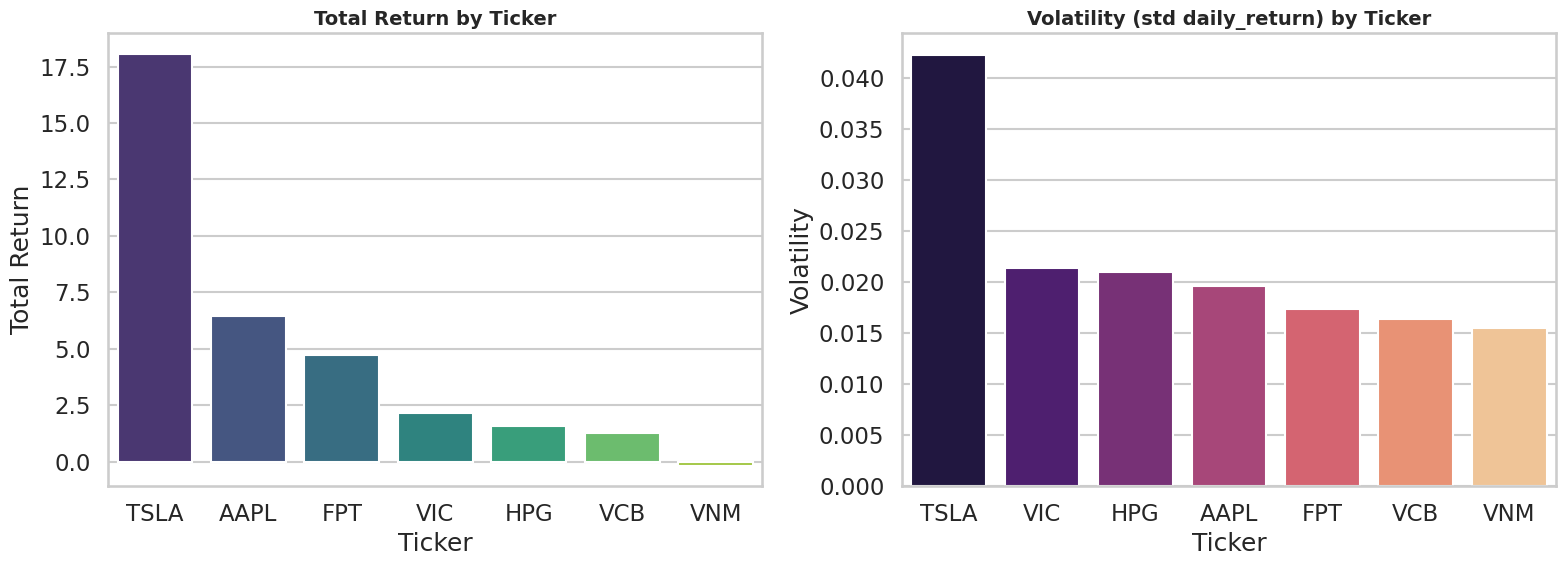

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=summary_pd.sort_values("total_return", ascending=False),
            x="ticker", y="total_return", ax=axes[0], palette="viridis")
axes[0].set_title("Total Return by Ticker", fontsize=14, weight="bold")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Total Return")

sns.barplot(data=summary_pd.sort_values("volatility", ascending=False),
            x="ticker", y="volatility", ax=axes[1], palette="magma")
axes[1].set_title("Volatility (std daily_return) by Ticker", fontsize=14, weight="bold")
axes[1].set_xlabel("Ticker")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()

## 8. Bieu do 3 - Correlation heatmap giua cac ticker

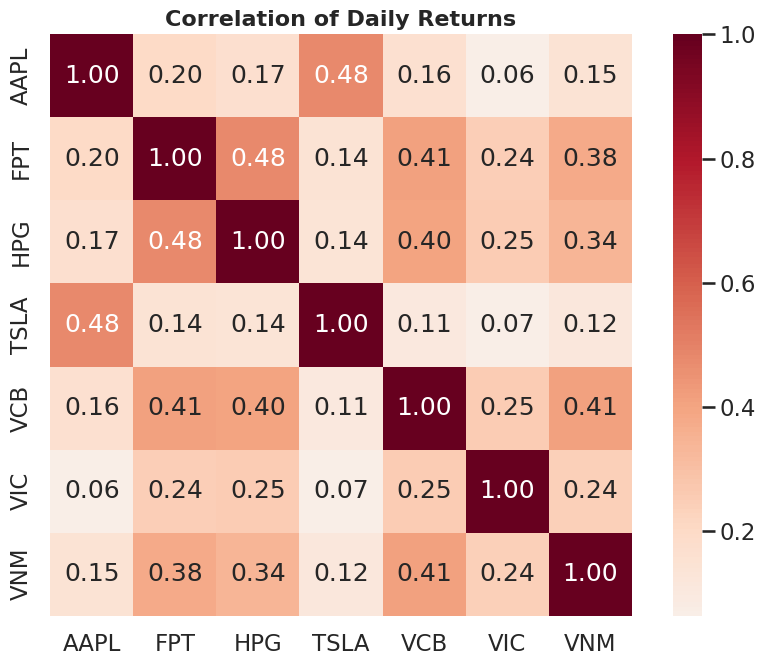

In [8]:
ret_pivot = (
    df_feat.select("time", "ticker", "daily_return")
    .groupBy("time").pivot("ticker").agg(F.first("daily_return"))
    .orderBy("time")
)

ret_pd = ret_pivot.toPandas().drop(columns=["time"], errors="ignore")
corr = ret_pd.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Correlation of Daily Returns", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

## 9. Bieu do 4 - Minh hoa tung ticker (Close vs MA7/MA30)

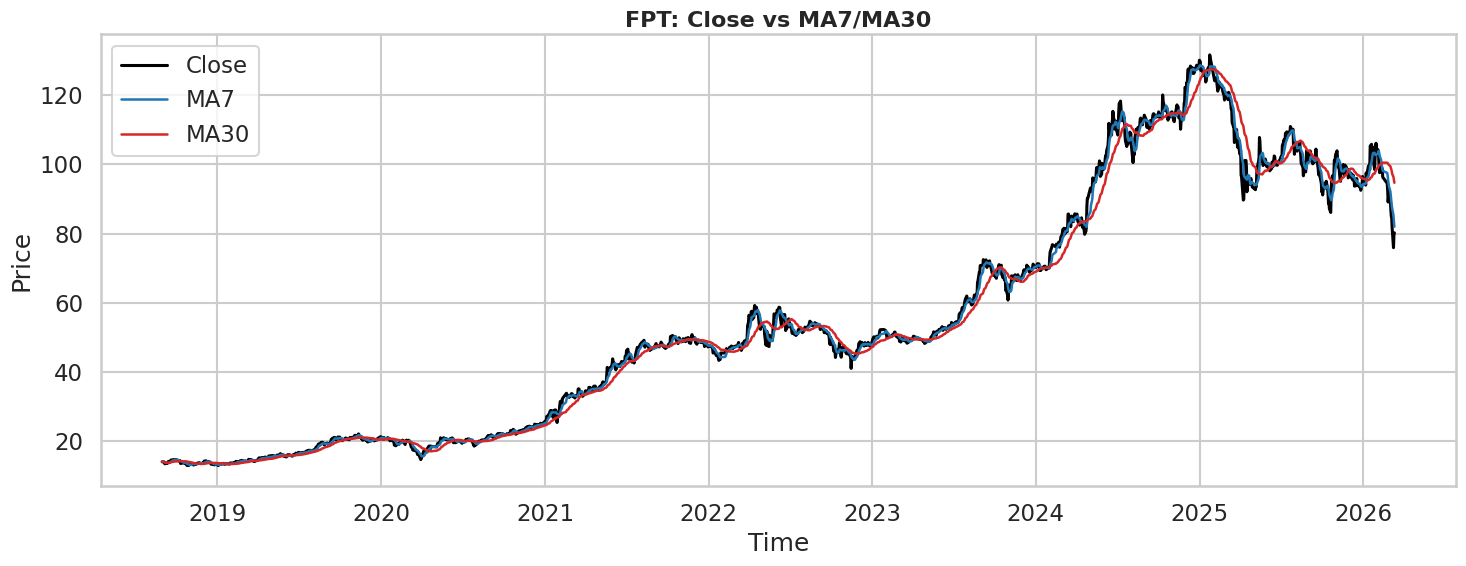

In [9]:
example_ticker = "FPT"
if df_feat.filter(F.col("ticker") == example_ticker).count() == 0:
    example_ticker = df_feat.select("ticker").first()[0]

single_pd = (
    df_feat.filter(F.col("ticker") == example_ticker)
    .select("time", "close", "ma7", "ma30")
    .orderBy("time")
    .toPandas()
)
single_pd["time"] = pd.to_datetime(single_pd["time"])

plt.figure(figsize=(15, 6))
plt.plot(single_pd["time"], single_pd["close"], label="Close", color="black", linewidth=2.2)
plt.plot(single_pd["time"], single_pd["ma7"], label="MA7", color="#1f77b4", linewidth=1.8)
plt.plot(single_pd["time"], single_pd["ma30"], label="MA30", color="#d62728", linewidth=1.8)
plt.title(f"{example_ticker}: Close vs MA7/MA30", fontsize=16, weight="bold")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Ket luan ngan gon cho bao cao

- Dung PySpark de xu ly va tinh toan time series theo tung ticker mot cach an toan (khong leakage).
- Dashboard tong hop cho thay su khac biet ro rang ve return va volatility giua cac ma.
- Nhan xet tu dong giup tiet kiem thoi gian viet bao cao, dong thoi van co co so dinh luong.
- Co the mo rong tiep voi mo hinh du bao nang cao (XGBoost, LSTM, Transformer) va walk-forward validation.

In [11]:
#Tu chon: dung Spark khi ket thuc
spark.stop()